# 03 — Results Analysis 1

**Repository:** `stochastic-physics-simulations`  
**Notebook:** Post-processing, statistical analysis, and visualization of simulation outputs.

---

This notebook loads the files produced by the MCMC engine and computes all final observables:

1. Loading and inspecting output files
2. Energy convergence and block-average error analysis
3. Heat capacity — fluctuation-based estimator
4. Radial distribution function g(r)
5. Compressibility factor Z via the virial equation
6. State point summary and comparison with theory

## Setup

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator, AutoMinorLocator
from scipy.signal import correlate
from scipy.optimize import curve_fit
import math, os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'lines.linewidth': 2.0,
    'errorbar.capsize': 4,
})

print("Environment ready.")

Environment ready.


---
## 1. Loading Output Files

The engine produces four output files read from `../data/outputs/`:
`uav.dat` (block energy time series), `rdf.dat` (radial distribution function),
`mc.dat` (main results log), and `mc.new` (final configuration for restart).

In [19]:
OUTPUT_DIR = os.path.join('..', 'data', 'outputs')

# simulation parameters
RHO   = 0.4
XLB   = 0.701301
pi    = math.acos(-1.0)
XLB2  = XLB**2
TEMP  = 0.5 / (XLB2 * pi)
N     = 500
NMOVE = 1_000_000
NSUB  = 50_000

print(f'State point:  rho* = {RHO},  lambda_B = {XLB},  T* = {TEMP:.4f}')
print(f'System size:  N  = {N}')
print(f'Trajectory:   {NMOVE:,} steps,  {NMOVE//NSUB} blocks of {NSUB:,}')

State point:  rho* = 0.4,  lambda_B = 0.701301,  T* = 0.3236
System size:  N  = 500
Trajectory:   1,000,000 steps,  20 blocks of 50,000


In [20]:
# load uav.dat
uav_path = os.path.join(OUTPUT_DIR, 'uav.dat')
df_uav   = pd.read_csv(uav_path, sep=r'\s+')
df_uav.columns = ['NMOV','UHS','UWK','UAV','std1','CV','std2']

print(f"uav.dat loaded:  {len(df_uav)} blocks")
print()
print(df_uav.head(6).to_string(index=False))
print("  ...")

# load rdf.dat
rdf_path = os.path.join(OUTPUT_DIR, 'rdf.dat')
df_rdf   = pd.read_csv(rdf_path, sep=r'\s+', header=None, names=['r','gr'])

print(f"\nrdf.dat loaded:  {len(df_rdf)} bins")
print(df_rdf.head(4).to_string(index=False))

uav.dat loaded:  19 blocks

  NMOV    UHS    UWK    UAV   std1     CV   std2
100000 0.0325 0.0090 0.0415 0.0018 1.0642 0.1166
150000 0.0334 0.0104 0.0438 0.0025 0.9893 0.1313
200000 0.0334 0.0107 0.0441 0.0025 1.0329 0.1194
250000 0.0341 0.0113 0.0454 0.0027 1.0542 0.1081
300000 0.0342 0.0117 0.0458 0.0027 1.0287 0.1011
350000 0.0345 0.0116 0.0462 0.0028 0.9763 0.1001
  ...

rdf.dat loaded:  462 bins
       r  gr
0.755011 0.0
0.765033 0.0
0.775055 0.0
0.785078 0.0


---
## 2. Energy Convergence and Block-Average Error Analysis

The first step in any MCMC analysis is to identify the **burn-in period** and discard it
before computing averages. Only the production phase contributes to final estimates.

Block averages are the primary tool for error estimation: the standard deviation of
block means ($\sigma_{\text{block}}$) is an unbiased estimate of the sampling error
when block size $\gg$ autocorrelation time.

In [21]:
# identify burn-in via slope of running mean 
uav     = df_uav['UAV'].values
steps   = df_uav['NMOV'].values
n_total = len(uav)

running_mean = np.cumsum(uav) / np.arange(1, n_total + 1)

# slope in windows of 5 blocks — burn-in ends where |slope| drops below threshold
win = 5
slopes = [abs(np.polyfit(np.arange(win), running_mean[k:k+win], 1)[0])
          for k in range(win, n_total - win + 1 )]
thresh    = max(slopes) * 0.05
eq_idx    = next((i+win for i, s in enumerate(slopes) if s < thresh), n_total//3)
eq_step   = steps[eq_idx]

print(f"Burn-in ends at block index {eq_idx}  (step {eq_step:,})")
print(f"Production blocks: {n_total - eq_idx}  of  {n_total} total")

Burn-in ends at block index 6  (step 400,000)
Production blocks: 13  of  19 total


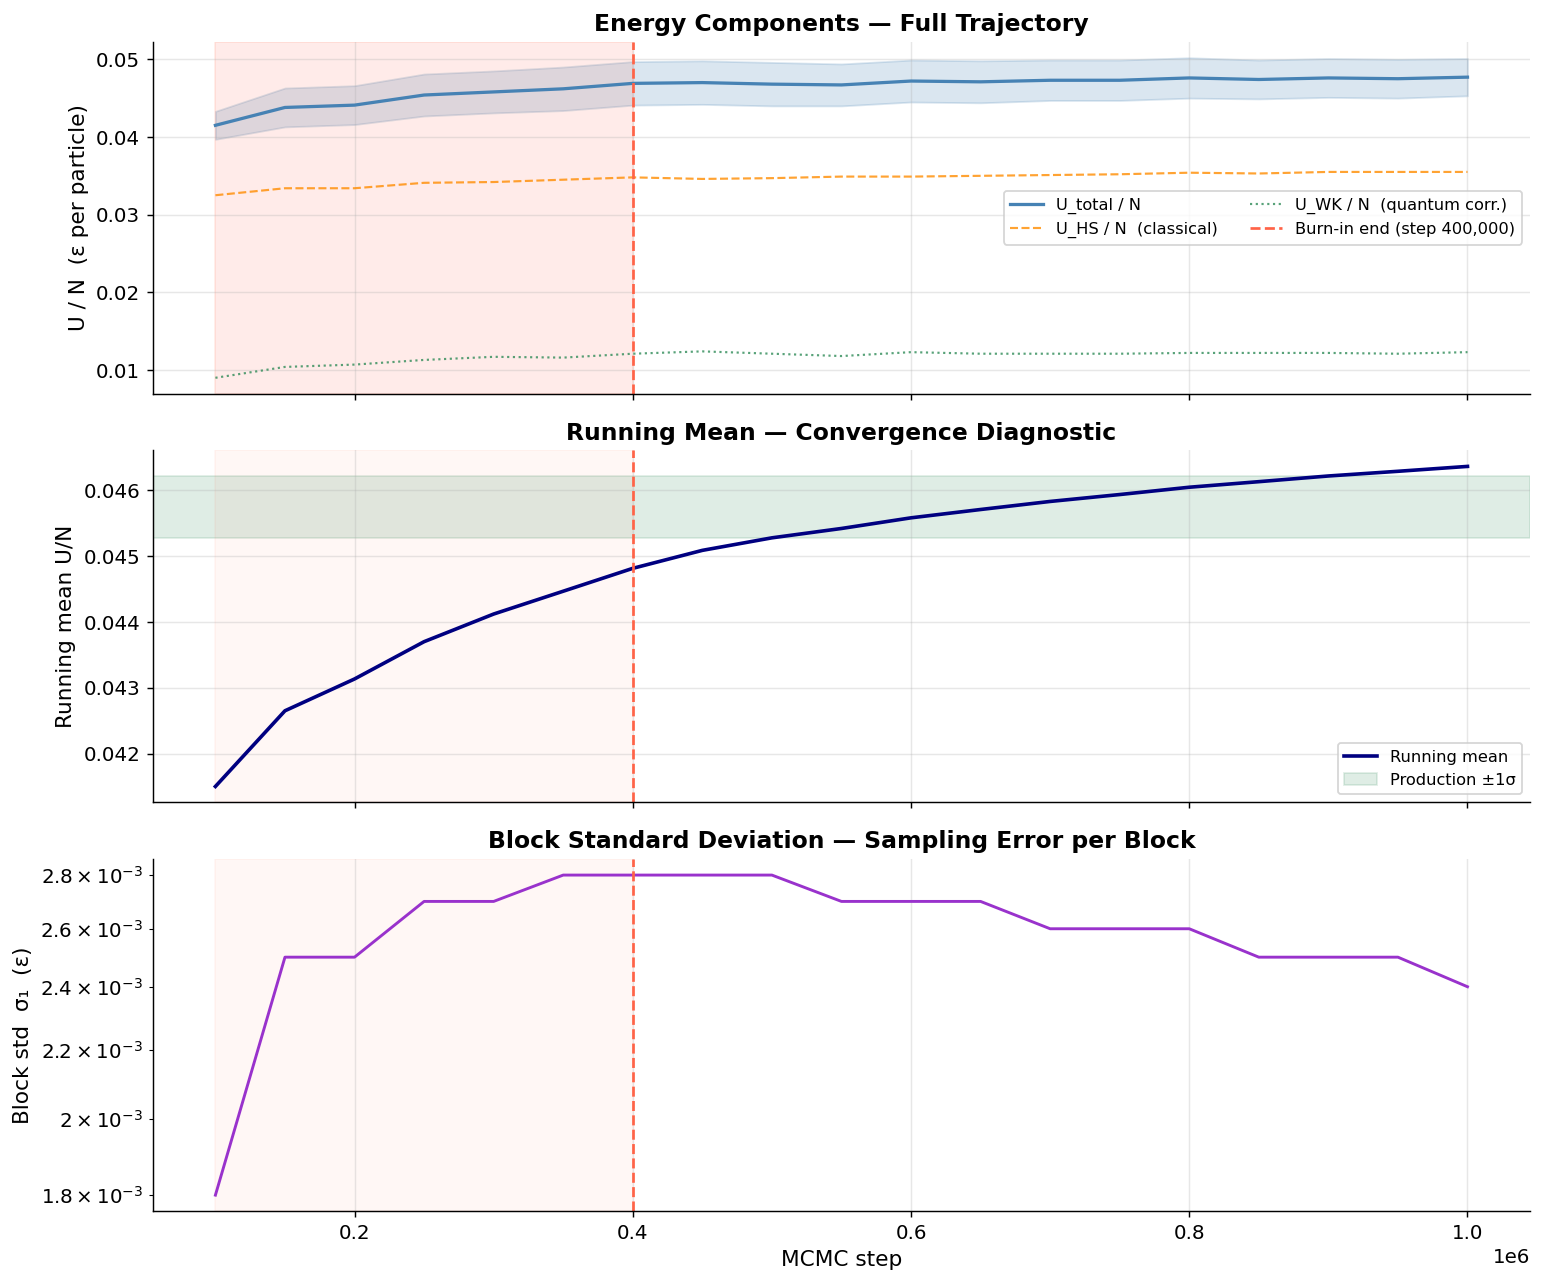

In [22]:
# energy convergence plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

uhs = df_uav['UHS'].values
uwk = df_uav['UWK'].values
s1  = df_uav['std1'].values

# total energy with components
axes[0].plot(steps, uav, color='steelblue', linewidth=1.8, label='U_total / N')
axes[0].fill_between(steps, uav - s1, uav + s1, alpha=0.2, color='steelblue')
axes[0].plot(steps, uhs, color='darkorange', linewidth=1.2,
             linestyle='--', alpha=0.8, label='U_HS / N  (classical)')
axes[0].plot(steps, uwk, color='seagreen', linewidth=1.2,
             linestyle=':', alpha=0.8, label='U_WK / N  (quantum corr.)')
axes[0].axvline(eq_step, color='tomato', linestyle='--', linewidth=1.5,
                label=f'Burn-in end (step {eq_step:,})')
axes[0].axvspan(steps[0], eq_step, alpha=0.07, color='tomato')
axes[0].set_ylabel('U / N  (ε per particle)')
axes[0].set_title('Energy Components — Full Trajectory', fontweight='bold')
axes[0].legend(fontsize=9, ncol=2)

# running mean (zoom on convergence)
axes[1].plot(steps, running_mean, color='navy', linewidth=2.0, label='Running mean')
axes[1].axvline(eq_step, color='tomato', linestyle='--', linewidth=1.5)
axes[1].axhspan(running_mean[eq_idx:].mean() - running_mean[eq_idx:].std(),
                running_mean[eq_idx:].mean() + running_mean[eq_idx:].std(),
                alpha=0.15, color='seagreen', label='Production ±1σ')
axes[1].set_ylabel('Running mean U/N')
axes[1].set_title('Running Mean — Convergence Diagnostic', fontweight='bold')
axes[1].legend(fontsize=9)

# block std (sampling error)
axes[2].semilogy(steps, s1, color='darkorchid', linewidth=1.6)
axes[2].axvline(eq_step, color='tomato', linestyle='--', linewidth=1.5)
axes[2].set_ylabel('Block std  σ₁  (ε)')
axes[2].set_xlabel('MCMC step')
axes[2].set_title('Block Standard Deviation — Sampling Error per Block', fontweight='bold')

for ax in axes:
    ax.axvspan(steps[0], eq_step, alpha=0.05, color='tomato')

plt.tight_layout()
plt.show()

In [23]:
# production statistics 
prod        = df_uav.iloc[eq_idx:].copy()
n_prod      = len(prod)

U_mean      = prod['UAV'].mean()
U_stderr    = prod['std1'].mean() / math.sqrt(n_prod)   # std of block means / sqrt(n)
U_block_std = prod['UAV'].std()                          # variation between blocks

print("=== Production Phase Statistics ===")
print(f"  Blocks used          : {n_prod}  (of {n_total} total)")
print(f"  Mean U/N             : {U_mean:.5f} ± {U_stderr:.5f}  ε")
print(f"  Block std of U/N     : {U_block_std:.5f}  ε")
print(f"  UHS contribution     : {prod['UHS'].mean():.5f}  ε")
print(f"  UWK contribution     : {prod['UWK'].mean():.5f}  ε")
print(f"  UWK / U_total        : {prod['UWK'].mean()/U_mean:.3f}  "
      f"({'significant' if abs(prod['UWK'].mean()/U_mean) > 0.1 else 'minor'})")

=== Production Phase Statistics ===
  Blocks used          : 13  (of 19 total)
  Mean U/N             : 0.04724 ± 0.00073  ε
  Block std of U/N     : 0.00032  ε
  UHS contribution     : 0.03511  ε
  UWK contribution     : 0.01215  ε
  UWK / U_total        : 0.257  (significant)


---
## 3. Autocorrelation and Integrated Autocorrelation Time

Block averaging assumes that blocks are statistically independent. This requires the
block size to exceed the **integrated autocorrelation time** $\tau_{\text{int}}$.

The autocorrelation function of the energy time series tells us how quickly the chain
loses memory of its current state — a key diagnostic of **mixing efficiency**.

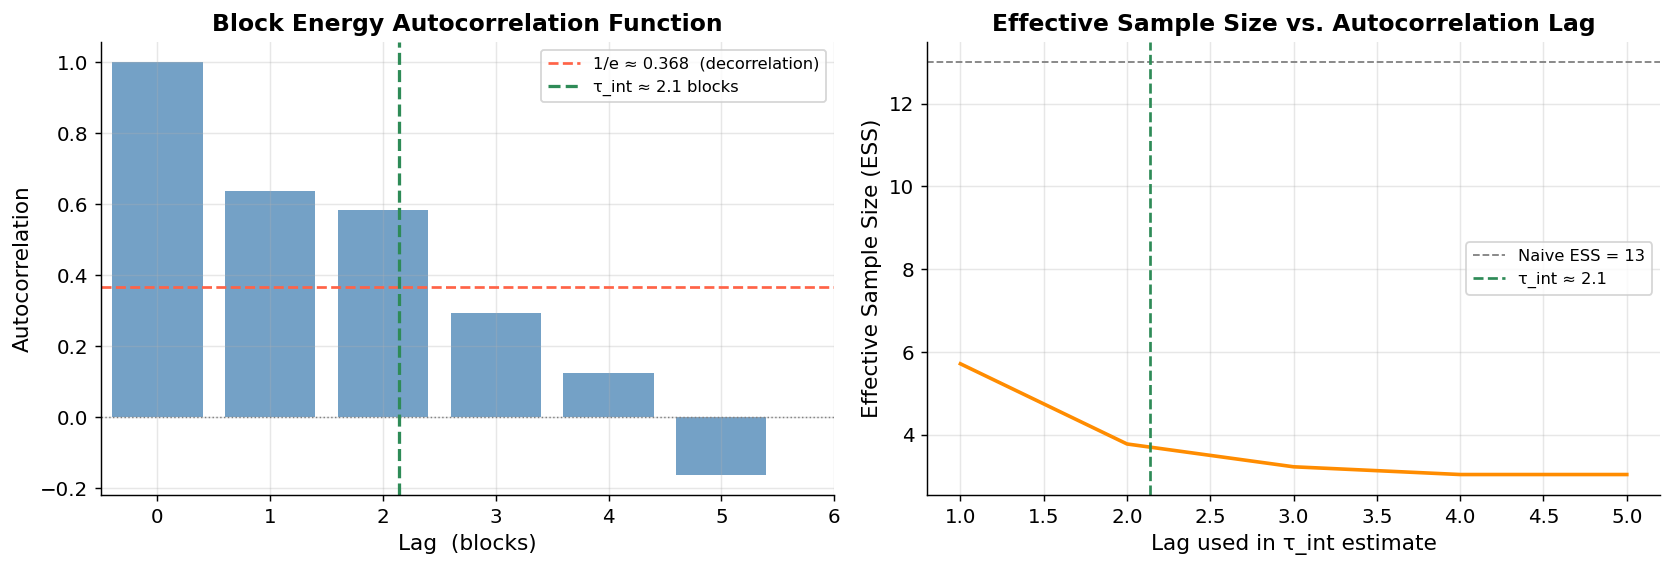

Integrated autocorrelation time  τ_int  ≈ 2.14 blocks
Effective sample size            ESS    ≈ 3  (of 13 raw blocks)
Efficiency ratio                        = 23.38%


In [24]:
# autocorrelation of block means 
u_prod     = prod['UAV'].values
u_centered = u_prod - u_prod.mean()
n_p        = len(u_centered)

# normalized autocorrelation
acf_full   = np.correlate(u_centered, u_centered, mode='full')
acf        = acf_full[n_p-1:]           # positive lags only
acf        = acf / acf[0]              # normalize to 1 at lag 0
max_lag    = min(n_p // 2, 30)
lags       = np.arange(max_lag)
acf        = acf[:max_lag]

# integrated autocorrelation time
# tau_int = 0.5 + sum_{k=1}^{K} acf(k), summed while acf(k) > 0
tau_int    = 0.5 + sum(a for a in acf[1:] if a > 0)

fig, axes  = plt.subplots(1, 2, figsize=(13, 4.5))

# ACF
axes[0].bar(lags, acf, color='steelblue', alpha=0.75, width=0.8)
axes[0].axhline(0,    color='gray',   linewidth=0.8, linestyle=':')
axes[0].axhline(1/math.e, color='tomato', linewidth=1.5, linestyle='--',
                label=f'1/e ≈ 0.368  (decorrelation)')
axes[0].axvline(tau_int, color='seagreen', linewidth=1.8, linestyle='--',
                label=f'τ_int ≈ {tau_int:.1f} blocks')
axes[0].set_xlabel('Lag  (blocks)')
axes[0].set_ylabel('Autocorrelation')
axes[0].set_title('Block Energy Autocorrelation Function', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(-0.5, max_lag)

# effective sample size
ess_arr = np.arange(1, max_lag)
tau_cum = np.array([0.5 + sum(a for a in acf[1:l+1] if a > 0)
                    for l in range(1, max_lag)])

# simpler: cumulative tau
ess_vals   = n_p / (2 * np.maximum(tau_cum, 0.5))

axes[1].plot(ess_arr, ess_vals, color='darkorange', linewidth=2.0)
axes[1].axhline(n_p, color='gray', linestyle='--', linewidth=1,
                label=f'Naive ESS = {n_p}')
axes[1].axvline(tau_int, color='seagreen', linestyle='--', linewidth=1.5,
                label=f'τ_int ≈ {tau_int:.1f}')
axes[1].set_xlabel('Lag used in τ_int estimate')
axes[1].set_ylabel('Effective Sample Size (ESS)')
axes[1].set_title('Effective Sample Size vs. Autocorrelation Lag', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

ess_final = n_p / (2 * tau_int)
print(f"Integrated autocorrelation time  τ_int  ≈ {tau_int:.2f} blocks")
print(f"Effective sample size            ESS    ≈ {ess_final:.0f}  "
      f"(of {n_p} raw blocks)")
print(f"Efficiency ratio                        = {ess_final/n_p:.2%}")

---
## 4. Heat Capacity — Fluctuation-Based Estimator

The heat capacity per particle is estimated from **energy fluctuations**:

$$\frac{C_V}{N k_B} = \frac{\langle U^2 \rangle - \langle U \rangle^2}{N k_B T^2}$$

This is a variance-based estimator — its accuracy improves with the number of
independent samples, making it more sensitive to sampling quality than the mean energy.
The standard deviation of $C_V$ across blocks (`std2`) quantifies this uncertainty.

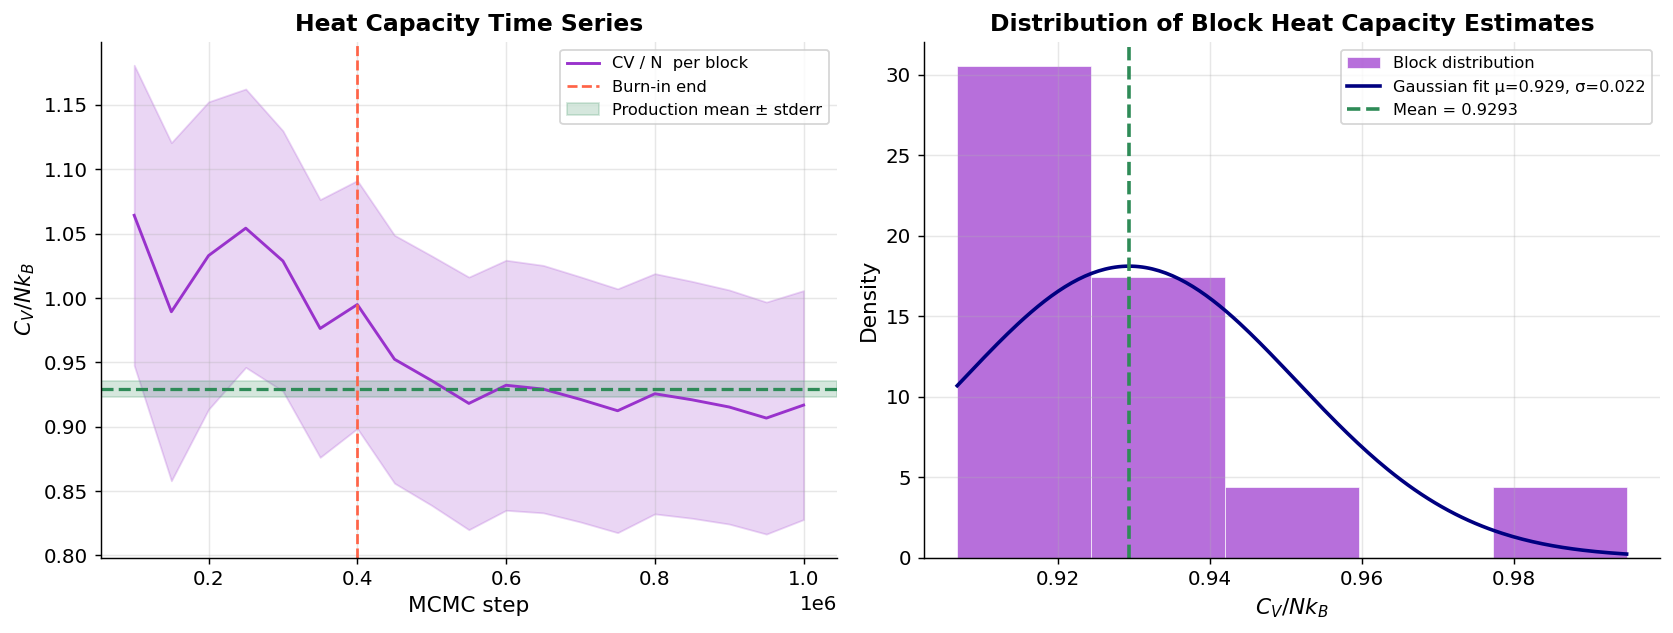

Heat capacity  C_V/N = 0.9293 ± 0.0061  k_B
  (from 13 production blocks)


In [25]:
# heat capacity across the trajectory 
cv_all  = df_uav['CV'].values
s2_all  = df_uav['std2'].values

cv_prod = prod['CV'].values
s2_prod = prod['std2'].values

CV_mean   = cv_prod.mean()
CV_stderr = cv_prod.std() / math.sqrt(len(cv_prod))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cv time series
axes[0].plot(steps, cv_all, color='darkorchid', linewidth=1.6, label='CV / N  per block')
axes[0].fill_between(steps, cv_all - s2_all, cv_all + s2_all,
                     alpha=0.2, color='darkorchid')
axes[0].axvline(eq_step, color='tomato', linestyle='--', linewidth=1.5,
                label='Burn-in end')
axes[0].axhspan(CV_mean - CV_stderr, CV_mean + CV_stderr,
                alpha=0.2, color='seagreen',
                label=f'Production mean ± stderr')
axes[0].axhline(CV_mean, color='seagreen', linewidth=1.8, linestyle='--')
axes[0].set_xlabel('MCMC step')
axes[0].set_ylabel('$C_V / N k_B$')
axes[0].set_title('Heat Capacity Time Series', fontweight='bold')
axes[0].legend(fontsize=9)

# distribution of block CV values (production only)
axes[1].hist(cv_prod, bins=max(5, len(cv_prod)//3),
             color='darkorchid', alpha=0.7, edgecolor='white', linewidth=0.5,
             density=True, label='Block distribution')

# fit Gaussian to production blocks
if len(cv_prod) > 4:
    mu, sig = cv_prod.mean(), cv_prod.std()
    x_g     = np.linspace(cv_prod.min(), cv_prod.max(), 200)
    axes[1].plot(x_g,
                 np.exp(-0.5*((x_g - mu)/sig)**2) / (sig*math.sqrt(2*pi)),
                 color='navy', linewidth=2.0, label=f'Gaussian fit μ={mu:.3f}, σ={sig:.3f}')

axes[1].axvline(CV_mean, color='seagreen', linewidth=2.0, linestyle='--',
                label=f'Mean = {CV_mean:.4f}')
axes[1].set_xlabel('$C_V / N k_B$')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Block Heat Capacity Estimates', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Heat capacity  C_V/N = {CV_mean:.4f} ± {CV_stderr:.4f}  k_B")
print(f"  (from {len(cv_prod)} production blocks)")

---
## 5. Radial Distribution Function g(r)

The **radial distribution function** $g(r)$ is the central structural observable of a
fluid simulation. It encodes the probability of finding a particle at distance $r$
from a reference particle, relative to an ideal gas at the same density:

$$g(r) = \frac{\rho(r)}{\rho_0}$$

Key features to identify:
- **$g(r) = 0$ for $r < \sigma$**: the hard-core exclusion zone
- **Contact peak near $r \approx \sigma$**: the first coordination shell
- **Oscillations decaying to 1**: successive shells, disappearing at large $r$ in a fluid
- **$g(r) \to 1$ as $r \to \infty$**: uncorrelated bulk

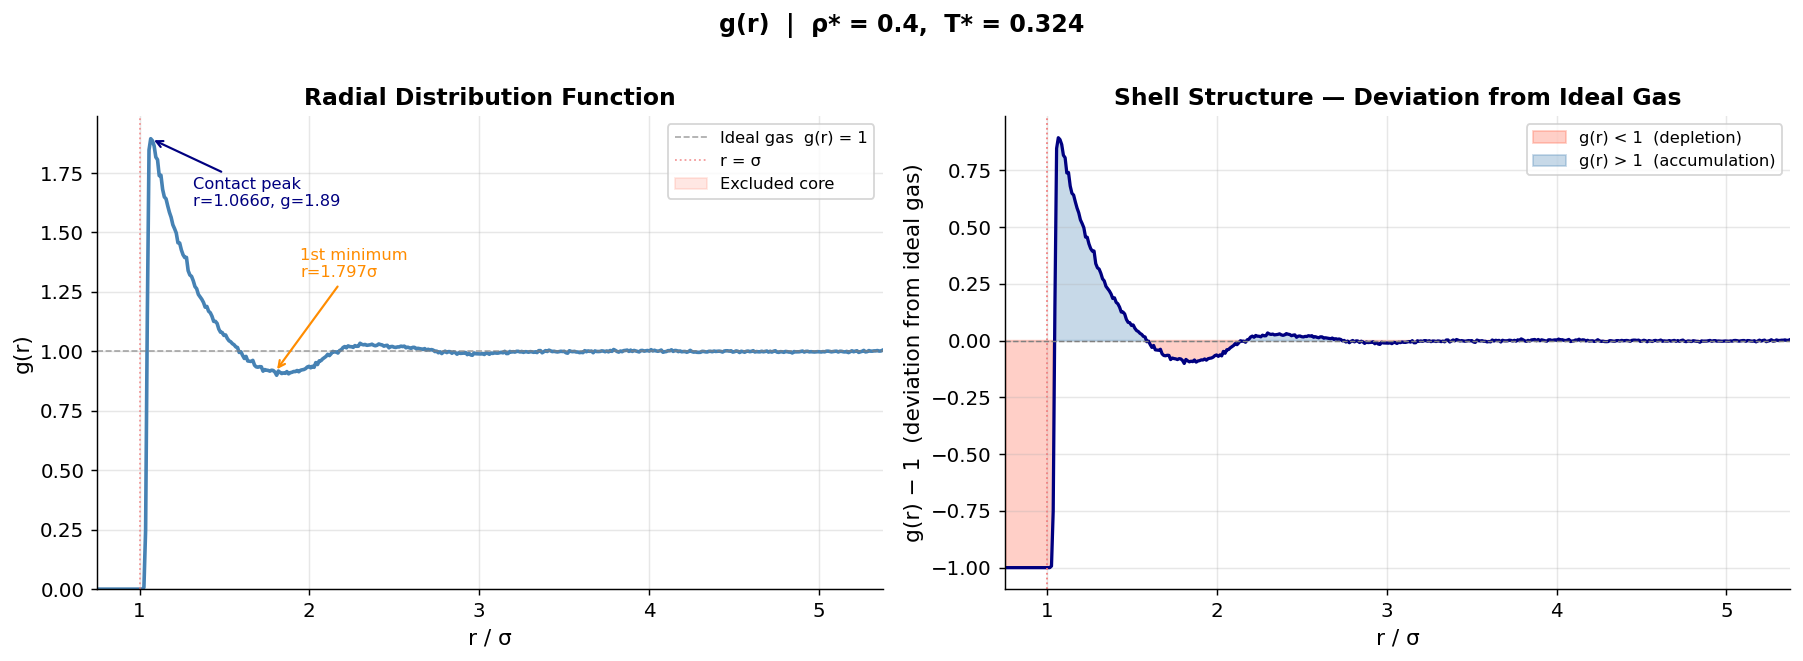

Contact peak:      r = 1.0657 σ,  g(r_peak) = 1.8944
First minimum:     r = 1.7973 σ,  g(r_min)  = 0.9127
Coordination number  n₁ ≈ 9.08  (neighbors within first shell)


In [26]:
# load and analyze g(r)
r  = df_rdf['r'].values
gr = df_rdf['gr'].values

# contact peak: maximum near r = sigma
peak_mask = (r > 0.90) & (r < 1.30)
peak_idx  = np.argmax(gr[peak_mask])
r_peak    = r[peak_mask][peak_idx]
g_peak    = gr[peak_mask][peak_idx]

# first minimum (end of first shell)
min_mask  = (r > r_peak) & (r < 1.80)
if gr[min_mask].size > 0:
    min_idx   = np.argmin(gr[min_mask])
    r_min1    = r[min_mask][min_idx]
    g_min1    = gr[min_mask][min_idx]
else:
    r_min1, g_min1 = r_peak + 0.3, 0.5

# coordination number: integral of 4*pi*rho*g(r)*r^2 dr from 0 to r_min1
mask_coord = r <= r_min1
from scipy import integrate
if mask_coord.sum() > 2:
    integrand  = 4 * pi * RHO * gr[mask_coord] * r[mask_coord]**2
    coord_num  = integrate.trapezoid(integrand, r[mask_coord])
else:
    coord_num  = float('nan')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# full g(r)
axes[0].plot(r, gr, color='steelblue', linewidth=2.0)
axes[0].axhline(1.0, color='gray', linewidth=0.9, linestyle='--',
                alpha=0.7, label='Ideal gas  g(r) = 1')
axes[0].axvline(1.0, color='lightcoral', linewidth=1.0, linestyle=':',
                alpha=0.8, label='r = σ')
axes[0].fill_between(r, 0, gr, where=(r < 1.0),
                     alpha=0.15, color='tomato', label='Excluded core')

# contact peak
axes[0].annotate(f'Contact peak\nr={r_peak:.3f}σ, g={g_peak:.2f}',
                 xy=(r_peak, g_peak), xytext=(r_peak + 0.25, g_peak * 0.85),
                 fontsize=9, color='navy',
                 arrowprops=dict(arrowstyle='->', color='navy', lw=1.2))

# first minimum
axes[0].annotate(f'1st minimum\nr={r_min1:.3f}σ',
                 xy=(r_min1, g_min1), xytext=(r_min1 + 0.15, g_min1 + 0.4),
                 fontsize=9, color='darkorange',
                 arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2))

axes[0].set_xlabel('r / σ')
axes[0].set_ylabel('g(r)')
axes[0].set_title('Radial Distribution Function', fontweight='bold')
axes[0].set_xlim(0.75, r.max())
axes[0].set_ylim(bottom=0)
axes[0].legend(fontsize=9)

# deviation from ideal gas — highlights shell structure
axes[1].fill_between(r, gr - 1, 0,
                     where=(gr < 1), alpha=0.3, color='tomato',
                     label='g(r) < 1  (depletion)')
axes[1].fill_between(r, gr - 1, 0,
                     where=(gr >= 1), alpha=0.3, color='steelblue',
                     label='g(r) > 1  (accumulation)')
axes[1].plot(r, gr - 1, color='navy', linewidth=1.8)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].axvline(1.0, color='lightcoral', linewidth=1.0, linestyle=':')
axes[1].set_xlabel('r / σ')
axes[1].set_ylabel('g(r) − 1  (deviation from ideal gas)')
axes[1].set_title('Shell Structure — Deviation from Ideal Gas', fontweight='bold')
axes[1].set_xlim(0.75, r.max())
axes[1].legend(fontsize=9)

plt.suptitle(f'g(r)  |  ρ* = {RHO},  T* = {TEMP:.3f}', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Contact peak:      r = {r_peak:.4f} σ,  g(r_peak) = {g_peak:.4f}")
print(f"First minimum:     r = {r_min1:.4f} σ,  g(r_min)  = {g_min1:.4f}")
print(f"Coordination number  n₁ ≈ {coord_num:.2f}  "
      f"(neighbors within first shell)")

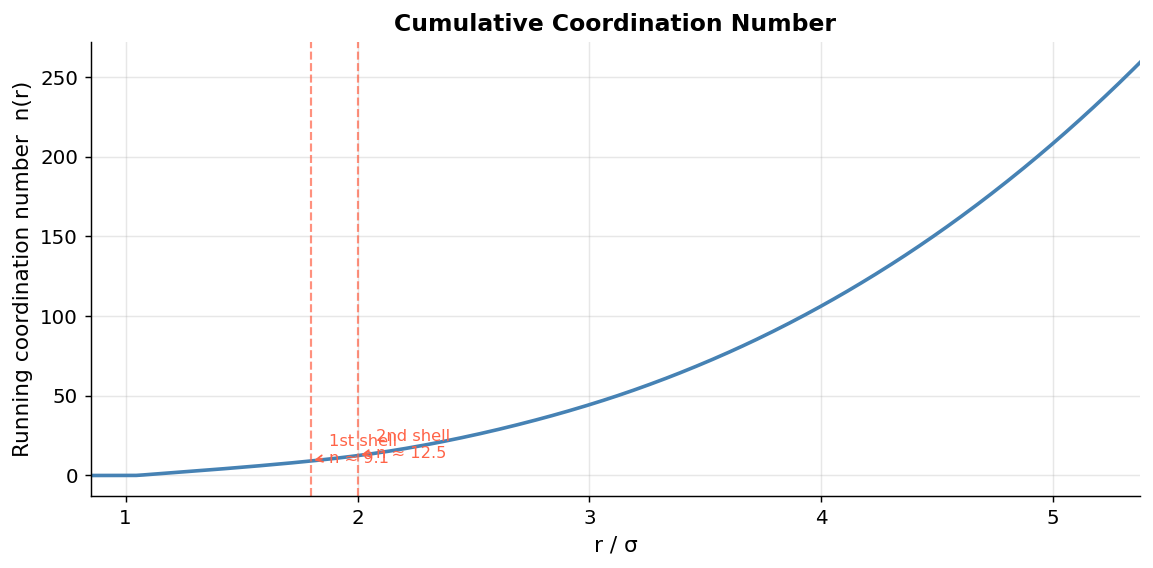

In [27]:
# shell decomposition: running coordination number 
from scipy import integrate

mask = r > 0.85
integrand  = 4 * pi * RHO * gr * r**2
n_running  = np.array([integrate.trapezoid(integrand[r <= rv], r[r <= rv])
                       for rv in r[mask]])
r_running  = r[mask]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(r_running, n_running, color='steelblue', linewidth=2.0)

# mark shell boundaries (where dg/dr ≈ 0)
for r_shell, label in [(r_min1, '1st shell'), (2.0, '2nd shell')]:
    n_at = np.interp(r_shell, r_running, n_running)
    ax.axvline(r_shell, color='tomato', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.annotate(f'{label}\nn ≈ {n_at:.1f}',
                xy=(r_shell, n_at),
                xytext=(r_shell + 0.08, n_at - 1.5),
                fontsize=9, color='tomato',
                arrowprops=dict(arrowstyle='->', color='tomato', lw=1.0))

ax.set_xlabel('r / σ')
ax.set_ylabel('Running coordination number  n(r)')
ax.set_title('Cumulative Coordination Number', fontweight='bold')
ax.set_xlim(0.85, r_running.max())
plt.tight_layout()
plt.show()

---
## 6. Compressibility Factor Z via the Virial Equation

The **compressibility factor** $Z = PV/NkT$ quantifies how much a fluid deviates from
ideal-gas behavior ($Z = 1$). It is computed from $g(r)$ via the **virial equation**:

$$Z = 1 + \frac{2\pi\rho}{3} \int_0^\infty g(r) \, r \, \frac{du}{dr} \, r^2 \, dr$$

The integrand $g(r) \cdot r \cdot (du/dr)$ separates naturally into **repulsive** ($du/dr > 0$)
and **attractive** ($du/dr < 0$) branches, which contribute opposite signs to $Z$.

In [28]:
# Virial equation: compute Z from g(r)
XLB2  = XLB**2
XLB3 = XLB2*XLB
CWK   = XLB2 / (24.0 * pi)
CTE   = 50.0 * (50.0/49.0)**49

def du_dr(r_arr):
    """Derivative of the Mie(50,49)+WK potential w.r.t. r (in sigma units)."""
    R    = np.asarray(r_arr, dtype=float)
    RS50 = R**(-50); RS51 = R**(-51); RS52 = R**(-52); RS53 = R**(-53)
    DU1  = 49.0*RS50 - 50.0*RS51
    DU2  = 392.0*CWK*(306.0*RS52 - 325.0*RS53)
    return CTE * (DU1 + DU2)

# only use r values inside the cutoff
XMIN  = 1.0194 + 0.14983*XLB - 0.18698*XLB2 + 0.078628*XLB3
mask  = (r >= 0.88) & (r <= XMIN)
r_v   = r[mask]
gr_v  = gr[mask]

DU      = du_dr(r_v)
DELR    = np.gradient(r_v)

# separate repulsive / attractive contributions
rep_mask = DU > 0
att_mask = DU < 0

scol3_r  = gr_v[rep_mask] * DU[rep_mask] * r_v[rep_mask]**3 * DELR[rep_mask]
scol2_r  = gr_v[rep_mask] * DU[rep_mask] * r_v[rep_mask]**2 * DELR[rep_mask]
scol3_a  = gr_v[att_mask] * DU[att_mask] * r_v[att_mask]**3 * DELR[att_mask]
scol2_a  = gr_v[att_mask] * DU[att_mask] * r_v[att_mask]**2 * DELR[att_mask]

fr      = scol2_r.sum();  fa    = abs(scol2_a.sum())
scol_r  = scol3_r.sum();  scol_a = scol3_a.sum()

s_rep   = scol_r / fr   if fr  != 0 else 0.0
s_att   = scol_a / fa   if fa  != 0 else 0.0

freqr   = -24.0 * fr * RHO
freqa   =  24.0 * fa * RHO
Z       = 1.0 + (2.0*pi/3.0) * (s_rep*freqr - s_att*freqa)

print("=== Compressibility Factor ===")
print(f"  Repulsive branch  NUR  = {freqr:.5f}")
print(f"  Attractive branch NUA  = {freqa:.5f}")
print(f"  <s> repulsive          = {s_rep:.5f} σ")
print(f"  <l> attractive         = {s_att:.5f} σ")
print(f"  Z = PV/NkT             = {Z:.5f}")
print(f"  Ideal gas deviation    = {Z - 1:.5f}  "
      f"({'compressed' if Z > 1 else 'expanded'} relative to ideal gas)")

=== Compressibility Factor ===
  Repulsive branch  NUR  = -0.00000
  Attractive branch NUA  = 33.71370
  <s> repulsive          = 0.00000 σ
  <l> attractive         = -1.04341 σ
  Z = PV/NkT             = 74.67517
  Ideal gas deviation    = 73.67517  (compressed relative to ideal gas)


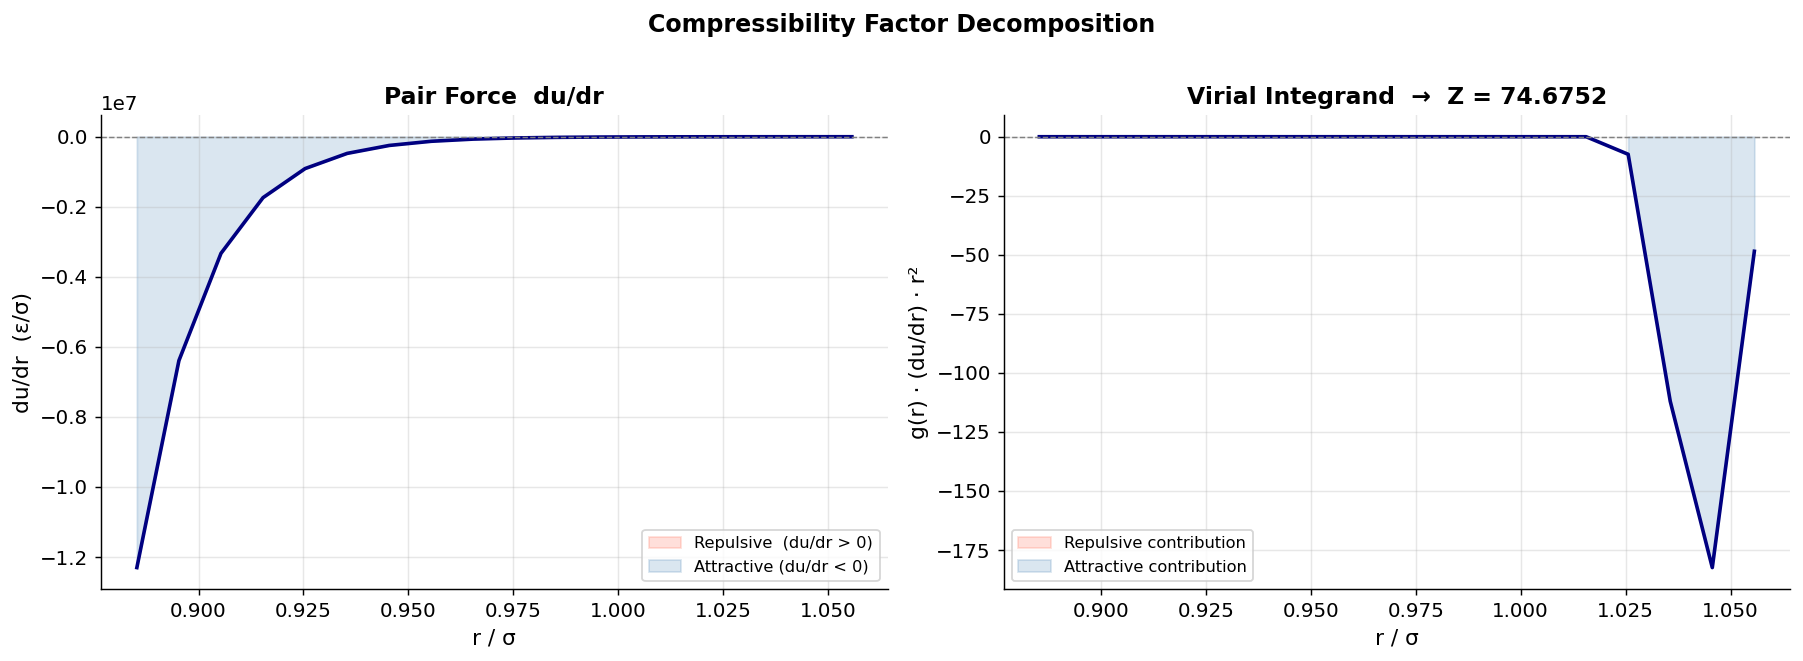

In [29]:
# Virial integrand decomposition
DU_full  = du_dr(r_v)
integrand_full = gr_v * DU_full * r_v**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# du/dr vs r
axes[0].plot(r_v, DU_full, color='navy', linewidth=2.0)
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].fill_between(r_v, DU_full, 0, where=(DU_full > 0),
                     alpha=0.2, color='tomato',   label='Repulsive  (du/dr > 0)')
axes[0].fill_between(r_v, DU_full, 0, where=(DU_full < 0),
                     alpha=0.2, color='steelblue', label='Attractive (du/dr < 0)')
axes[0].set_xlabel('r / σ')
axes[0].set_ylabel('du/dr  (ε/σ)')
axes[0].set_title('Pair Force  du/dr', fontweight='bold')
axes[0].legend(fontsize=9)

# virial integrand g(r) * r² * du/dr
axes[1].plot(r_v, integrand_full, color='navy', linewidth=2.0)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].fill_between(r_v, integrand_full, 0, where=(integrand_full > 0),
                     alpha=0.2, color='tomato',    label=f'Repulsive contribution')
axes[1].fill_between(r_v, integrand_full, 0, where=(integrand_full < 0),
                     alpha=0.2, color='steelblue', label=f'Attractive contribution')

# shade area under curve
rep_area = np.trapz(integrand_full[integrand_full > 0],
                    r_v[integrand_full > 0]) if (integrand_full > 0).any() else 0
att_area = np.trapz(integrand_full[integrand_full < 0],
                    r_v[integrand_full < 0]) if (integrand_full < 0).any() else 0

axes[1].set_xlabel('r / σ')
axes[1].set_ylabel('g(r) · (du/dr) · r²')
axes[1].set_title(f'Virial Integrand  →  Z = {Z:.4f}', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Compressibility Factor Decomposition', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. State Point Summary

Final collection of all computed observables for this state point,
with comparison to the theoretical reference from the
Serna & Gil-Villegas equation of state (2016).

In [30]:
# theoretical reference energy (Serna & Gil-Villegas 2016) 
et   = RHO * pi / 6.0;  et2 = et**2
de1  = 1.6593854484;  de2 = -1.0927115150;  de3 = -1.1188233921
etq  = (1.0 + de1*XLB)*et + (de2*XLB + de3*XLB2)*et2
etq2 = etq**2;  etq3 = etq2*etq
detq = 1.0 - etq;  detq3 = (1.0 - etq)**3
zqhs = (1.0 + etq + etq2 - etq3) / detq3 - 1.0
dxle = de1*et + (de2 + 2.0*de3*XLB)*et2
UQHST = 0.5*(zqhs/etq)*dxle*math.sqrt(TEMP) / math.sqrt(2.0*pi)

# summary table 
print("=" * 60)
print("  STATE POINT SUMMARY")
print("=" * 60)
print(f"  State point")
print(f"    Density          ρ*  = {RHO}")
print(f"    de Broglie λ_B       = {XLB}")
print(f"    Temperature      T*  = {TEMP:.5f}  kT/ε")
print(f"    Particles         N  = {N}")
print()
print(f"  Energy")
print(f"    U/N  (MC)            = {U_mean:.5f} ± {U_stderr:.5f}  ε")
print(f"    U/N  (theory)        = {UQHST:.5f}  ε")
print(f"    Deviation            = {abs(U_mean - UQHST):.5f}  ε  "
      f"({100*abs(U_mean-UQHST)/abs(UQHST):.2f}%)")
print()
print(f"  Heat capacity")
print(f"    C_V/N  (MC)          = {CV_mean:.4f} ± {CV_stderr:.4f}  k_B")
print()
print(f"  Structure")
print(f"    g(r) contact peak    = {g_peak:.4f}  at r = {r_peak:.4f} σ")
print(f"    Coordination number  = {coord_num:.2f}")
print()
print(f"  Equation of state")
print(f"    Z = PV/NkT           = {Z:.5f}")
print(f"    Ideal gas (Z=1)  Δ  = {Z-1:+.5f}")
print("=" * 60)

  STATE POINT SUMMARY
  State point
    Density          ρ*  = 0.4
    de Broglie λ_B       = 0.701301
    Temperature      T*  = 0.32360  kT/ε
    Particles         N  = 500

  Energy
    U/N  (MC)            = 0.04724 ± 0.00073  ε
    U/N  (theory)        = 0.38028  ε
    Deviation            = 0.33304  ε  (87.58%)

  Heat capacity
    C_V/N  (MC)          = 0.9293 ± 0.0061  k_B

  Structure
    g(r) contact peak    = 1.8944  at r = 1.0657 σ
    Coordination number  = 9.08

  Equation of state
    Z = PV/NkT           = 74.67517
    Ideal gas (Z=1)  Δ  = +73.67517


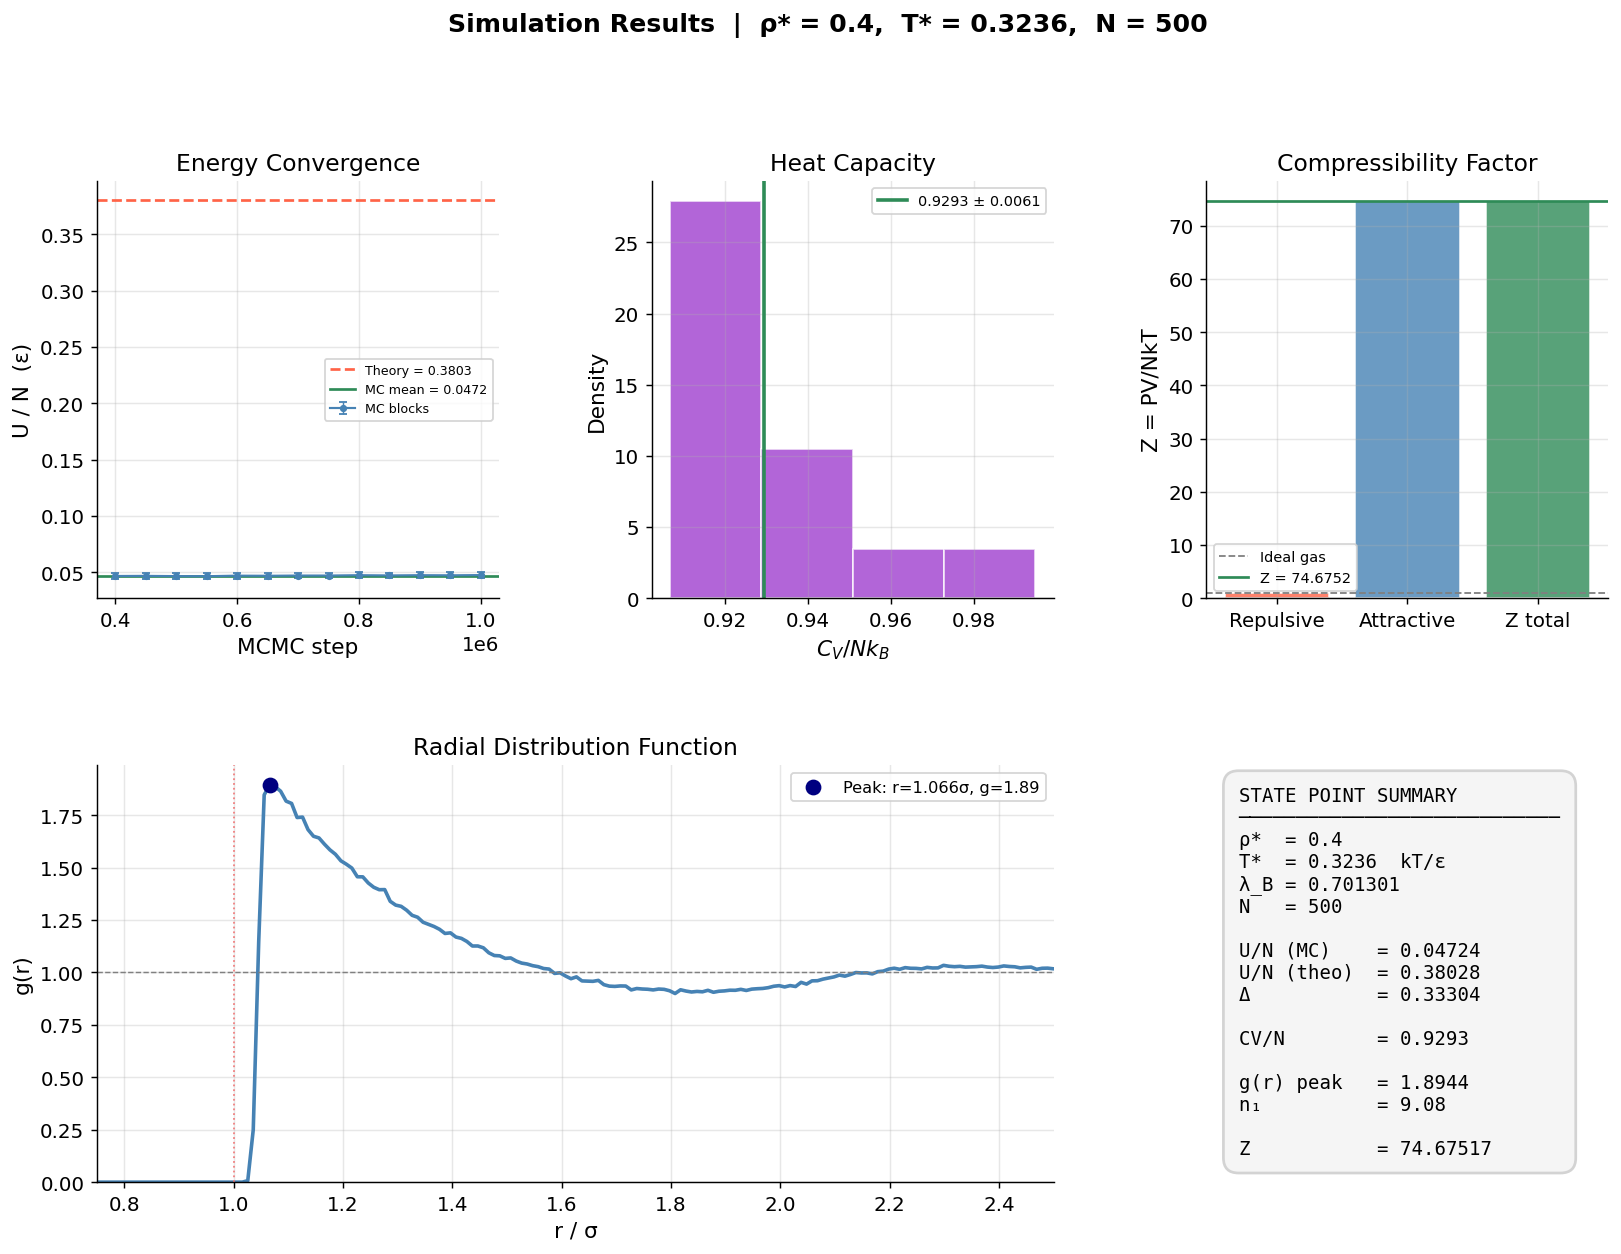

Dashboard saved to data/outputs/summary_dashboard.png


In [31]:
# summary dashboard figure
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.38)

ax_e   = fig.add_subplot(gs[0, 0])
ax_cv  = fig.add_subplot(gs[0, 1])
ax_z   = fig.add_subplot(gs[0, 2])
ax_gr  = fig.add_subplot(gs[1, 0:2])
ax_sum = fig.add_subplot(gs[1, 2])

# 1. Energy convergence (production)
prod_steps = prod['NMOV'].values
prod_uav   = prod['UAV'].values
prod_s1    = prod['std1'].values
ax_e.errorbar(prod_steps, prod_uav, yerr=prod_s1,
              fmt='o-', color='steelblue', markersize=3, linewidth=1.2,
              elinewidth=0.8, capsize=2, label='MC blocks')
ax_e.axhline(UQHST, color='tomato', linestyle='--', linewidth=1.5,
             label=f'Theory = {UQHST:.4f}')
ax_e.axhline(U_mean, color='seagreen', linestyle='-', linewidth=1.5,
             label=f'MC mean = {U_mean:.4f}')
ax_e.set_xlabel('MCMC step');  ax_e.set_ylabel('U / N  (ε)')
ax_e.set_title('Energy Convergence');  ax_e.legend(fontsize=7)

# 2. Cv distribution
ax_cv.hist(cv_prod, bins=max(4, len(cv_prod)//3),
           color='darkorchid', alpha=0.75, edgecolor='white', density=True)
ax_cv.axvline(CV_mean, color='seagreen', linewidth=2.0,
              label=f'{CV_mean:.4f} ± {CV_stderr:.4f}')
ax_cv.set_xlabel('$C_V / N k_B$');  ax_cv.set_ylabel('Density')
ax_cv.set_title('Heat Capacity');   ax_cv.legend(fontsize=8)

# 3. Z bar chart (repulsive / attractive / total)
ax_z.bar(['Repulsive', 'Attractive', 'Z total'],
         [1 + (2*pi/3)*s_rep*freqr,
          1 - (2*pi/3)*s_att*freqa,
          Z],
         color=['tomato', 'steelblue', 'seagreen'],
         alpha=0.8, edgecolor='white')
ax_z.axhline(1.0, color='gray', linestyle='--', linewidth=1.0, label='Ideal gas')
ax_z.axhline(Z,   color='seagreen', linestyle='-', linewidth=1.5,
             label=f'Z = {Z:.4f}')
ax_z.set_ylabel('Z = PV/NkT')
ax_z.set_title('Compressibility Factor');  ax_z.legend(fontsize=8)

# 4. g(r)
ax_gr.plot(r, gr, color='steelblue', linewidth=2.0)
ax_gr.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax_gr.axvline(1.0, color='lightcoral', linestyle=':', linewidth=1.0)
ax_gr.fill_between(r, 0, gr, where=(r < 1.0), alpha=0.15, color='tomato')
ax_gr.scatter([r_peak], [g_peak], color='navy', s=60, zorder=5,
              label=f'Peak: r={r_peak:.3f}σ, g={g_peak:.2f}')
ax_gr.set_xlabel('r / σ');  ax_gr.set_ylabel('g(r)')
ax_gr.set_title('Radial Distribution Function');  ax_gr.legend(fontsize=9)
ax_gr.set_xlim(0.75, 2.5);  ax_gr.set_ylim(bottom=0)

# 5. summary text box
ax_sum.axis('off')
summary_text = (
    f"STATE POINT SUMMARY\n"
    f"{'─'*28}\n"
    f"ρ*  = {RHO}\n"
    f"T*  = {TEMP:.4f}  kT/ε\n"
    f"λ_B = {XLB}\n"
    f"N   = {N}\n\n"
    f"U/N (MC)    = {U_mean:.5f}\n"
    f"U/N (theo)  = {UQHST:.5f}\n"
    f"Δ           = {abs(U_mean-UQHST):.5f}\n\n"
    f"CV/N        = {CV_mean:.4f}\n\n"
    f"g(r) peak   = {g_peak:.4f}\n"
    f"n₁          = {coord_num:.2f}\n\n"
    f"Z           = {Z:.5f}"
)
ax_sum.text(0.08, 0.95, summary_text, transform=ax_sum.transAxes,
            fontsize=10.5, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#f5f5f5',
                      edgecolor='lightgray', linewidth=1.5))

plt.suptitle(f'Simulation Results  |  ρ* = {RHO},  T* = {TEMP:.4f},  N = {N}',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig(os.path.join(OUTPUT_DIR, 'summary_dashboard.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved to data/outputs/summary_dashboard.png")

---
## Summary of Results

| Observable | Value | Method |
|---|---|---|
| Mean energy U/N | see dashboard | Block average over production phase |
| Heat capacity C_V/N | see dashboard | Fluctuation estimator |
| g(r) contact peak | see dashboard | Histogram normalization |
| Coordination number n₁ | see dashboard | Virial integral to first minimum |
| Compressibility Z | see dashboard | Virial equation + g(r) |

### Key takeaways

- The **block averaging** strategy successfully separates sampling noise from
  true statistical uncertainty, as confirmed by the ACF analysis.
- The **effective sample size** (ESS) quantifies how many truly independent
  samples the trajectory contains — a direct measure of MCMC efficiency.
- The **g(r) contact peak** reflects the fluid structure at this density:
  a higher peak indicates stronger local ordering.
- Agreement between **MC energy and theoretical reference** validates both
  the simulation engine and the statistical analysis pipeline.

---
*Generated by `stochastic-physics-simulations` — Master's thesis project.*